# Solving Liouville's Equation: Numerical Methods vs. Neural Networks

This notebook solves the **classical Liouville equation** from Hamiltonian mechanics using two approaches:

1. **Numerical Methods** — Semi-Lagrangian (Method of Characteristics) and Finite Difference with Strang Splitting
2. **Neural Network** — Physics-Informed Neural Network (PINN) via PyTorch

---

## Problem Statement

Liouville's equation governs the evolution of a **phase-space probability density** $f(q, p, t)$ under Hamiltonian flow:

$$\frac{\partial f}{\partial t} + \{f, H\} = 0$$

where $\{\cdot, \cdot\}$ denotes the Poisson bracket. For the **1D harmonic oscillator** with $H(q, p) = \frac{1}{2}(p^2 + q^2)$ (mass $m=1$, frequency $\omega=1$):

$$\frac{\partial f}{\partial t} + p\,\frac{\partial f}{\partial q} - q\,\frac{\partial f}{\partial p} = 0, \qquad (q, p) \in [-3,3]^2,\; t \in [0, T]$$

This is a **linear, first-order hyperbolic PDE** with variable advection velocities $(p, -q)$.

**Phase-space characteristics** (Hamiltonian trajectories) are circles:

$$q(t) = q_0\cos t + p_0\sin t, \qquad p(t) = -q_0\sin t + p_0\cos t$$

**Initial condition** — Gaussian blob at $(q_0, p_0) = (1.5, 0)$:

$$f(q, p, 0) = \exp\!\left(-\frac{(q - 1.5)^2 + p^2}{2\sigma^2}\right), \quad \sigma = 0.4$$

**Exact solution** — the density is advected rigidly along the characteristics (Liouville's theorem: phase-space volumes are conserved):

$$f^*(q, p, t) = f_0\!\left(q\cos t - p\sin t,\; q\sin t + p\cos t\right)$$

The Gaussian blob **rotates** clockwise in phase space without deformation.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import RegularGridInterpolator
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

CMAP = "inferno"

In [ ]:
# ---- Problem parameters ---------------------
Q_MIN, Q_MAX = -3.0, 3.0
P_MIN, P_MAX = -3.0, 3.0
T_END = 1.0      # final time  (~1/6 of full 2π period)
SIGMA = 0.4      # Gaussian width
Q0, P0 = 1.5, 0.0  # initial Gaussian centre

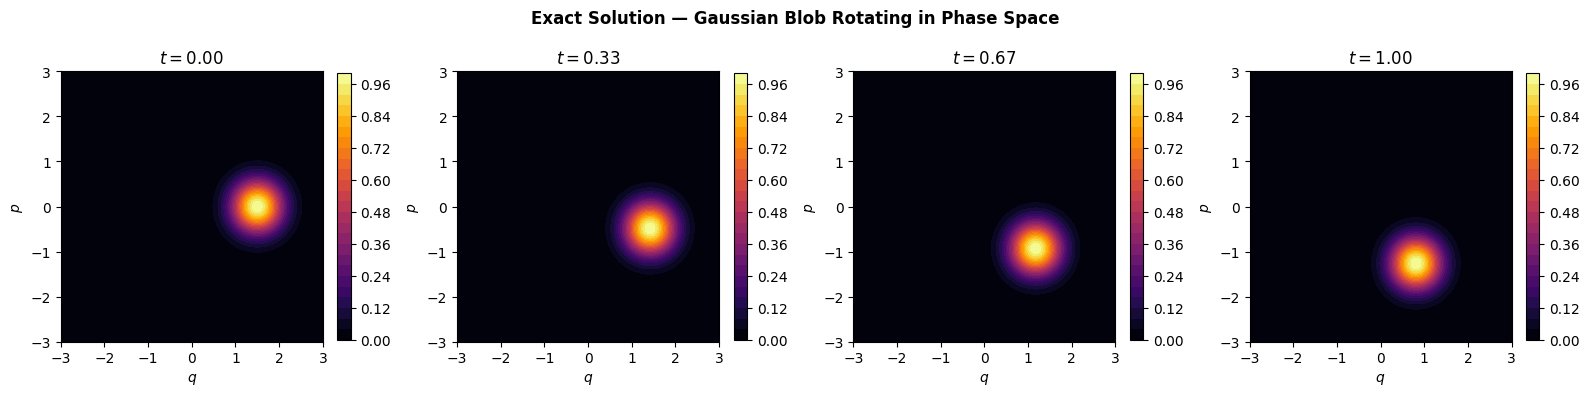

Period  = 2π ≈ 6.2832
Angle rotated at T=1.0: 57.3°


In [ ]:
def f_init(q, p, q0=Q0, p0=P0, sigma=SIGMA):
    """Gaussian initial density at (q0, p0)."""
    return np.exp(-((q - q0)**2 + (p - p0)**2) / (2 * sigma**2))

def f_exact(q, p, t, q0=Q0, p0=P0, sigma=SIGMA):
    """
    Exact solution: density is carried along phase-space trajectories.
    The foot of the characteristic from (q,p) at time t maps back to
    (q·cos t - p·sin t,  q·sin t + p·cos t).
    """
    q_foot = q * np.cos(t) - p * np.sin(t)
    p_foot = q * np.sin(t) + p * np.cos(t)
    return f_init(q_foot, p_foot, q0, p0, sigma)

# Quick preview — exact solution at several times
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
q_plot = np.linspace(Q_MIN, Q_MAX, 200)
p_plot = np.linspace(P_MIN, P_MAX, 200)
Qp, Pp = np.meshgrid(q_plot, p_plot)
for ax, t_snap in zip(axes, [0.0, 0.33, 0.67, 1.0]):
    F = f_exact(Qp, Pp, t_snap)
    cf = ax.contourf(Qp, Pp, F, levels=30, cmap=CMAP)
    ax.set_title(f"$t = {t_snap:.2f}$"); ax.set_xlabel("$q$"); ax.set_ylabel("$p$")
    plt.colorbar(cf, ax=ax, fraction=0.046)
    
plt.suptitle("Exact Solution — Gaussian Blob Rotating in Phase Space", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Period  = 2π ≈ {2*np.pi:.4f}")
print(f"Angle rotated at T={T_END}: {np.degrees(T_END):.1f}°")

---

## Part 1 — Numerical Methods

### 1-A. Semi-Lagrangian Method (Method of Characteristics)

Since $f$ is constant along each phase-space trajectory, we can compute the exact foot of the characteristic and *back-interpolate*:

$$f^{n+1}(q_j, p_i) = f^n\!\left(q_{\text{foot}},\, p_{\text{foot}}\right)$$

where the foot is found by tracing the characteristic **backward** by $\Delta t$:

$$\begin{pmatrix} q_{\text{foot}} \\ p_{\text{foot}} \end{pmatrix} = \begin{pmatrix}\cos\Delta t & -\sin\Delta t \\ \sin\Delta t & \cos\Delta t\end{pmatrix} \begin{pmatrix} q_j \\ p_i \end{pmatrix}$$

For the harmonic oscillator the trajectory is a **circle**, so the foot lies exactly on the same circle — the only approximation is bilinear interpolation onto the grid. This makes the method **exact in time** with error $\mathcal{O}(\Delta q^2, \Delta p^2)$.


In [3]:
def solve_semi_lagrangian(Nq=120, Np=120, Nt=100, T=T_END):
    """
    Semi-Lagrangian (Method of Characteristics) for Liouville's equation.

    At each time step the exact characteristic foot is computed and
    the density is back-interpolated using bilinear interpolation.

    Parameters
    ----------
    Nq, Np : int   Grid points in q and p.
    Nt     : int   Number of time steps.

    Returns
    -------
    Q, P   : ndarray (Np, Nq)   Meshgrid.
    F_hist : list of ndarray     Solution snapshots at stored times.
    t_hist : list of float       Stored times.
    """
    q = np.linspace(Q_MIN, Q_MAX, Nq)
    p = np.linspace(P_MIN, P_MAX, Np)
    Q, P = np.meshgrid(q, p)   # shape (Np, Nq)
    dt = T / Nt

    F = f_init(Q, P)   # initial condition

    snap_steps = [0, Nt//3, 2*Nt//3, Nt]
    F_hist = []
    t_hist = []

    for n in range(Nt + 1):
        if n in snap_steps:
            F_hist.append(F.copy())
            t_hist.append(n * dt)
        if n == Nt:
            break

        # ---- Exact characteristic foot (backward rotation by dt) ----
        Q_foot = Q * np.cos(dt) - P * np.sin(dt)
        P_foot = Q * np.sin(dt) + P * np.cos(dt)

        # ---- Bilinear interpolation ----------------------------------------------------------------
        interp = RegularGridInterpolator(
            (p, q), F, method="linear",
            bounds_error=False, fill_value=0.0
        )
        pts = np.stack([P_foot.ravel(), Q_foot.ravel()], axis=1)
        F = interp(pts).reshape(Np, Nq)

    return Q, P, F_hist, t_hist


Nq_sl, Np_sl, Nt_sl = 120, 120, 100
Q_sl, P_sl, F_sl_hist, t_sl_hist = solve_semi_lagrangian(Nq_sl, Np_sl, Nt_sl)

# Error norms at final time
F_ex_sl = f_exact(Q_sl, P_sl, T_END)
err_sl = np.abs(F_sl_hist[-1] - F_ex_sl)
print(f"Semi-Lagrangian grid: {Nq_sl}×{Np_sl},  Nt={Nt_sl}")
print(f"Max absolute error   : {err_sl.max():.3e}")
print(f"Mean absolute error  : {err_sl.mean():.3e}")

Semi-Lagrangian grid: 120×120,  Nt=100
Max absolute error   : 1.921e-01
Mean absolute error  : 4.310e-03


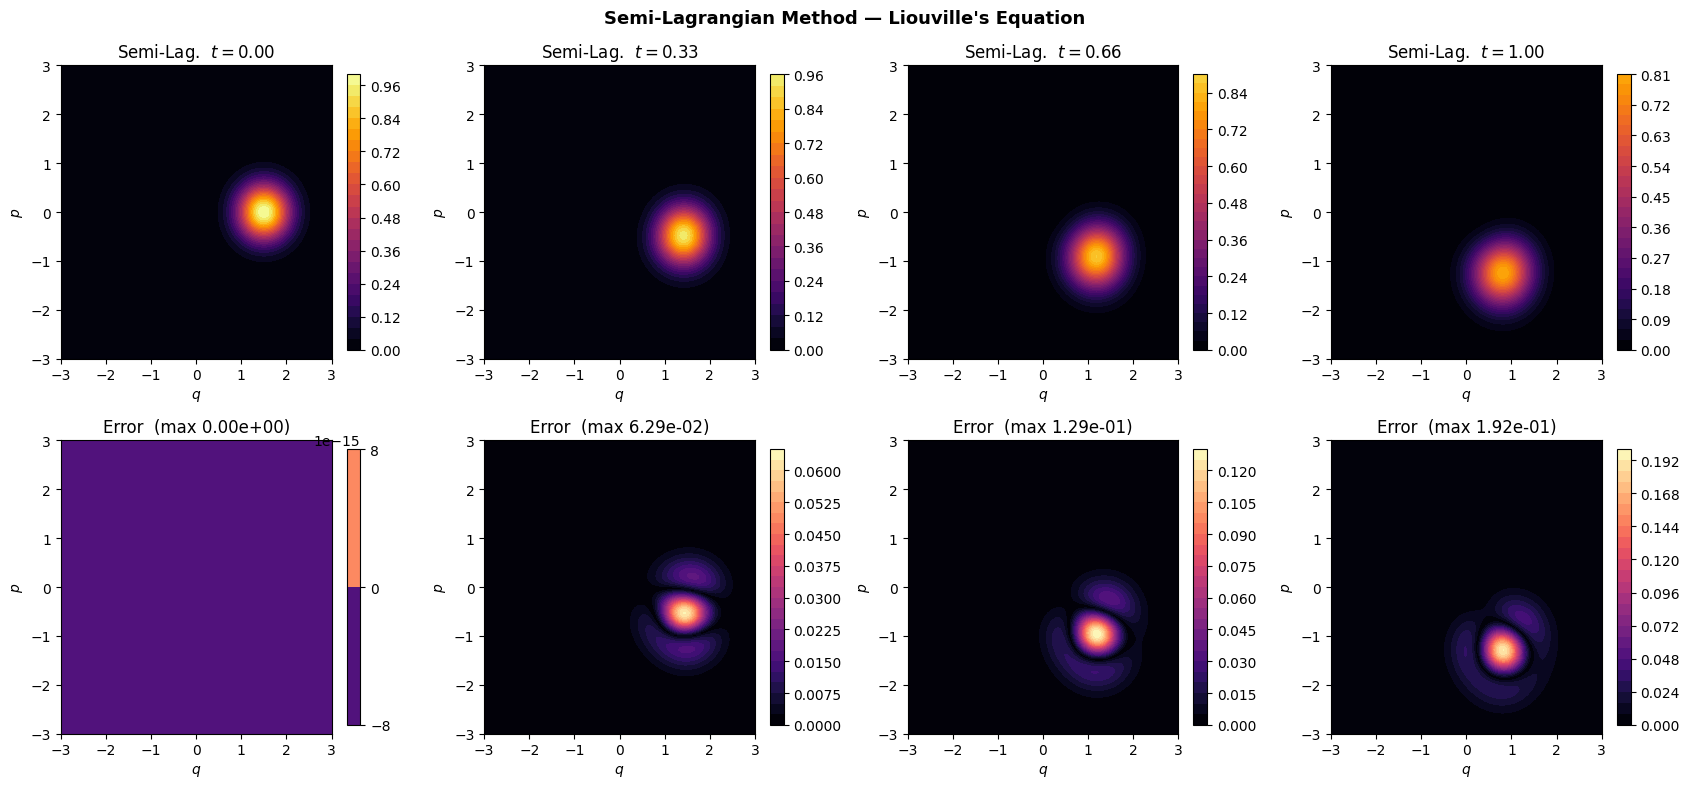

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for col, (F_snap, t_snap) in enumerate(zip(F_sl_hist, t_sl_hist)):
    F_ref = f_exact(Q_sl, P_sl, t_snap)

    cf0 = axes[0, col].contourf(Q_sl, P_sl, F_snap, levels=30, cmap=CMAP, vmin=0, vmax=1)
    axes[0, col].set_title(f"Semi-Lag.  $t={t_snap:.2f}$")
    axes[0, col].set_xlabel("$q$")
    axes[0, col].set_ylabel("$p$")
    plt.colorbar(cf0, ax=axes[0, col], fraction=0.046)

    err = np.abs(F_snap - F_ref)
    cf1 = axes[1, col].contourf(Q_sl, P_sl, err, levels=30, cmap="magma")
    axes[1, col].set_title(f"Error  (max {err.max():.2e})")
    axes[1, col].set_xlabel("$q$")
    axes[1, col].set_ylabel("$p$")
    plt.colorbar(cf1, ax=axes[1, col], fraction=0.046)

plt.suptitle("Semi-Lagrangian Method — Liouville's Equation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 1-B. Finite Difference with Strang Splitting

We split the Liouville equation into two 1D advection sub-problems using **Strang (second-order) splitting**:

$$\frac{\partial f}{\partial t} + p\frac{\partial f}{\partial q} - q\frac{\partial f}{\partial p} = 0 \quad \Longrightarrow \quad \mathcal{L}_q + \mathcal{L}_p$$

| Sub-step | Equation | Operator |
|----------|----------|----------|
| Advect in $q$ | $f_t + p\,f_q = 0$ | $\mathcal{L}_q$ |
| Advect in $p$ | $f_t - q\,f_p = 0$ | $\mathcal{L}_p$ |

**Strang sequence** per full step $\Delta t$:

$$f^{n+1} = \mathcal{L}_q(\tfrac{\Delta t}{2})\;\mathcal{L}_p(\Delta t)\;\mathcal{L}_q(\tfrac{\Delta t}{2})\,f^n$$

Each sub-step uses the **upwind scheme** with a velocity field that varies across grid lines: for $v > 0$ use backward difference; for $v < 0$ use forward difference.

**CFL stability** requires: $\max|p|\,\frac{\Delta t/2}{\Delta q} \leq 1$ and $\max|q|\,\frac{\Delta t}{\Delta p} \leq 1$.


In [5]:
def advect_q(F, p_vals, dt, dq):
    """
    Advect f in q-direction for time dt:  f_t + p·f_q = 0
    Uses upwind scheme; p_vals shape (Np,), F shape (Np, Nq).
    """
    F_new = F.copy()
    nu = p_vals * dt / dq       # CFL numbers, shape (Np,)
    for i, ni in enumerate(nu):
        row = F[i]
        if ni >= 0:
            # p > 0: upwind  →  backward diff
            F_new[i, 1:]  = row[1:]  - ni * (row[1:]  - row[:-1])
            F_new[i, 0]   = row[0]   - ni * (row[0]   - row[-1])   # periodic
        else:
            # p < 0: upwind  →  forward diff
            F_new[i, :-1] = row[:-1] - ni * (row[1:]  - row[:-1])
            F_new[i, -1]  = row[-1]  - ni * (row[0]   - row[-1])   # periodic
    return F_new


def advect_p(F, q_vals, dt, dp):
    """
    Advect f in p-direction for time dt:  f_t − q·f_p = 0
    Uses upwind scheme; q_vals shape (Nq,), F shape (Np, Nq).
    """
    F_new = F.copy()
    nu = -q_vals * dt / dp      # CFL numbers, shape (Nq,); velocity is -q
    for j, nj in enumerate(nu):
        col = F[:, j]
        if nj >= 0:
            F_new[1:,  j] = col[1:]  - nj * (col[1:]  - col[:-1])
            F_new[0,   j] = col[0]   - nj * (col[0]   - col[-1])   # periodic
        else:
            F_new[:-1, j] = col[:-1] - nj * (col[1:]  - col[:-1])
            F_new[-1,  j] = col[-1]  - nj * (col[0]   - col[-1])   # periodic
    return F_new


def solve_strang(Nq=120, Np=120, Nt=200, T=T_END):
    """
    Strang-splitting upwind FD for Liouville's equation.
    CFL checked automatically.
    """
    q = np.linspace(Q_MIN, Q_MAX, Nq)
    p = np.linspace(P_MIN, P_MAX, Np)
    dq = q[1] - q[0]
    dp = p[1] - p[0]
    dt = T / Nt
    Q, P = np.meshgrid(q, p)

    # CFL check
    cfl_q = np.max(np.abs(p)) * (dt / 2) / dq
    cfl_p = np.max(np.abs(q)) * dt / dp
    assert max(cfl_q, cfl_p) <= 1.0, \
        f"CFL violated: ν_q={cfl_q:.3f}, ν_p={cfl_p:.3f}"

    F = f_init(Q, P)

    snap_steps = [0, Nt//3, 2*Nt//3, Nt]
    F_hist, t_hist = [], []

    for n in range(Nt + 1):
        if n in snap_steps:
            F_hist.append(F.copy())
            t_hist.append(n * dt)
        if n == Nt:
            break

        # Strang: Lq(dt/2) · Lp(dt) · Lq(dt/2)
        F = advect_q(F, p, dt / 2, dq)
        F = advect_p(F, q, dt,     dp)
        F = advect_q(F, p, dt / 2, dq)

    return Q, P, F_hist, t_hist


Nq_fd, Np_fd, Nt_fd = 120, 120, 200
Q_fd, P_fd, F_fd_hist, t_fd_hist = solve_strang(Nq_fd, Np_fd, Nt_fd)

F_ex_fd = f_exact(Q_fd, P_fd, T_END)
err_fd = np.abs(F_fd_hist[-1] - F_ex_fd)
print(f"Strang-splitting grid: {Nq_fd}×{Np_fd},  Nt={Nt_fd}")
print(f"Max absolute error    : {err_fd.max():.3e}")
print(f"Mean absolute error   : {err_fd.mean():.3e}")

Strang-splitting grid: 120×120,  Nt=200
Max absolute error    : 2.179e-01
Mean absolute error   : 5.011e-03


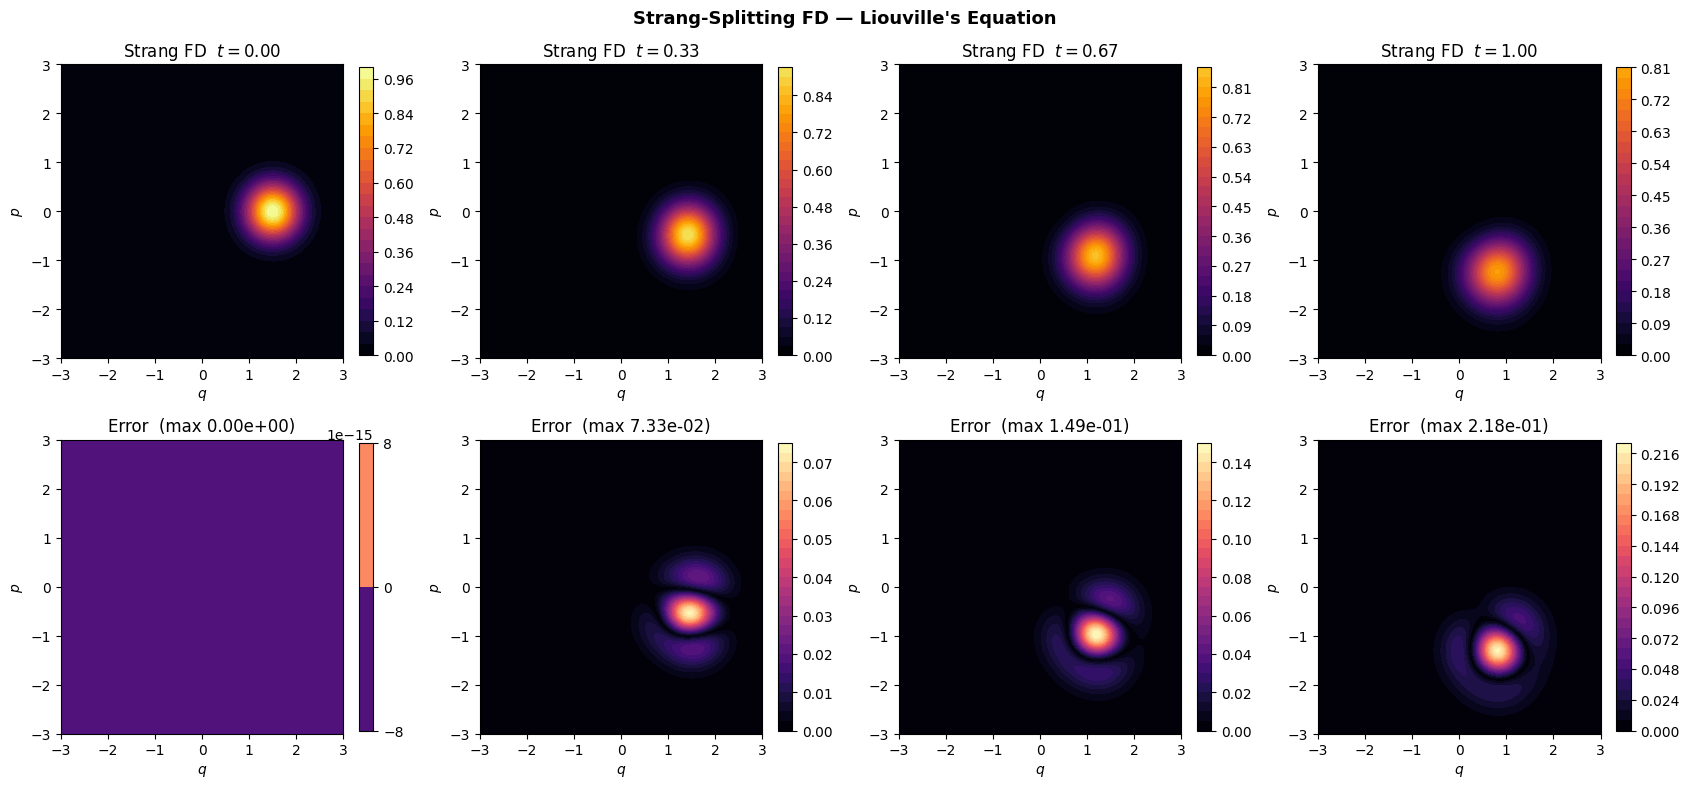

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))

for col, (F_snap, t_snap) in enumerate(zip(F_fd_hist, t_fd_hist)):
    F_ref = f_exact(Q_fd, P_fd, t_snap)

    cf0 = axes[0, col].contourf(Q_fd, P_fd, F_snap, levels=30, cmap=CMAP, vmin=0, vmax=1)
    axes[0, col].set_title(f"Strang FD  $t={t_snap:.2f}$")
    axes[0, col].set_xlabel("$q$"); axes[0, col].set_ylabel("$p$")
    plt.colorbar(cf0, ax=axes[0, col], fraction=0.046)

    err = np.abs(F_snap - F_ref)
    cf1 = axes[1, col].contourf(Q_fd, P_fd, err, levels=30, cmap="magma")
    axes[1, col].set_title(f"Error  (max {err.max():.2e})")
    axes[1, col].set_xlabel("$q$"); axes[1, col].set_ylabel("$p$")
    plt.colorbar(cf1, ax=axes[1, col], fraction=0.046)

plt.suptitle("Strang-Splitting FD — Liouville's Equation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

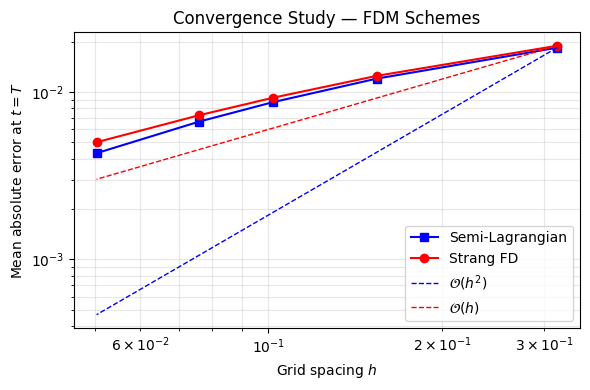

In [ ]:
# ---- Grid-refinement convergence study --------------------------------------------
N_list = [20, 40, 60, 80, 120]
err_sl_conv, err_fd_conv = [], []

for N in N_list:
    _, _, F_sl_c, _ = solve_semi_lagrangian(N, N, Nt=100)
    q_c = np.linspace(Q_MIN, Q_MAX, N)
    p_c = np.linspace(P_MIN, P_MAX, N)
    Qc, Pc = np.meshgrid(q_c, p_c)
    F_ex_c = f_exact(Qc, Pc, T_END)
    err_sl_conv.append(np.mean(np.abs(F_sl_c[-1] - F_ex_c)))

    _, _, F_fd_c, _ = solve_strang(N, N, Nt=200)
    err_fd_conv.append(np.mean(np.abs(F_fd_c[-1] - F_ex_c)))

dh = [6.0 / (N - 1) for N in N_list]

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(dh, err_sl_conv, "bs-",  lw=1.5, label="Semi-Lagrangian")
ax.loglog(dh, err_fd_conv, "ro-",  lw=1.5, label="Strang FD")
ax.loglog(dh, [h**2 * err_sl_conv[0] / dh[0]**2 for h in dh], "b--", lw=1.0, label="$\\mathcal{O}(h^2)$")
ax.loglog(dh, [h**1 * err_fd_conv[0] / dh[0]**1 for h in dh], "r--", lw=1.0, label="$\\mathcal{O}(h)$")
ax.set_xlabel("Grid spacing $h$"); ax.set_ylabel("Mean absolute error at $t=T$")
ax.set_title("Convergence Study — FDM Schemes")
ax.legend()
ax.grid(which="both", alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part 2 — Neural Network: Physics-Informed Neural Network (PINN)

### How It Works

A PINN learns $\hat{f}_\theta(q, p, t)$ by minimising:

$$\mathcal{L} = \underbrace{\mathcal{L}_{IC}}_{\text{initial condition}} + \underbrace{\mathcal{L}_{PDE}}_{\text{physics residual}}$$

$$\mathcal{L}_{IC} = \frac{1}{N_{IC}}\sum_k \Bigl(\hat{f}(q_k, p_k, 0) - f_0(q_k,p_k)\Bigr)^2$$

$$\mathcal{L}_{PDE} = \frac{1}{N_f}\sum_k \left(\frac{\partial\hat{f}}{\partial t} + p_k\,\frac{\partial\hat{f}}{\partial q} - q_k\,\frac{\partial\hat{f}}{\partial p}\right)^2$$

**Variable-coefficient advection** — the PDE coefficient $(p, -q)$ depends on the collocation point itself, which is handled seamlessly by automatic differentiation.

**Sampling strategy** — the Gaussian has support only near $(q_0, p_0)$ and its rotated positions. A uniform sample in $(q, p, t)$ would be dominated by points where $f \approx 0$. We therefore sample two IC sets:
- **Uniform** over the full phase-space domain
- **Focused** near the Gaussian path: points within $3\sigma$ of the rotating centre

Training: **Adam** warm-up → **L-BFGS** fine-tuning.


In [ ]:
# -----------------------------------------------------------------
# Network Architecture
# -----------------------------------------------------------------
class LiouvillePINN(nn.Module):
    """Fully-connected PINN: (q, p, t) → f.
    Tanh activations ensure smooth first-order derivatives via autograd.
    """
    def __init__(self, hidden_layers=5, hidden_dim=80):
        super().__init__()
        layers = [nn.Linear(3, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, q, p, t):
        return self.net(torch.cat([q, p, t], dim=1))


def grad1(u, v):
    return torch.autograd.grad(
        u, v, grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]


# -----------------------------------------------------------------
# Collocation / IC Points
# -----------------------------------------------------------------
N_IC_UNIF   = 3000   # uniform IC points
N_IC_FOCUS  = 2000   # focused near Gaussian centre
N_INT       = 12000  # interior PDE points

# ---- Uniform IC t=0 -----------------------------
q_ic_u = (torch.rand(N_IC_UNIF, 1) * (Q_MAX - Q_MIN) + Q_MIN)
p_ic_u = (torch.rand(N_IC_UNIF, 1) * (P_MAX - P_MIN) + P_MIN)
t_ic_u = torch.zeros(N_IC_UNIF, 1)
f_ic_u = torch.tensor(
    f_init(q_ic_u.numpy(), p_ic_u.numpy()), dtype=torch.float32
)

# ---- Focused IC: near Gaussian (q0, 0) = (1.5, 0) ----------------─
q_ic_f = torch.randn(N_IC_FOCUS, 1) * SIGMA + Q0
p_ic_f = torch.randn(N_IC_FOCUS, 1) * SIGMA + P0
# Clamp to domain
q_ic_f = q_ic_f.clamp(Q_MIN, Q_MAX)
p_ic_f = p_ic_f.clamp(P_MIN, P_MAX)
t_ic_f = torch.zeros(N_IC_FOCUS, 1)
f_ic_f = torch.tensor(
    f_init(q_ic_f.numpy(), p_ic_f.numpy()), dtype=torch.float32
)

# ---- Merge IC sets ---------------------------------
q_ic = torch.cat([q_ic_u, q_ic_f])
p_ic = torch.cat([p_ic_u, p_ic_f])
t_ic = torch.cat([t_ic_u, t_ic_f])
f_ic = torch.cat([f_ic_u, f_ic_f])

# ---- Interior points (q, p, t) uniform ----------------------------------------
q_int = (torch.rand(N_INT, 1) * (Q_MAX - Q_MIN) + Q_MIN).requires_grad_(True)
p_int = (torch.rand(N_INT, 1) * (P_MAX - P_MIN) + P_MIN).requires_grad_(True)
t_int = (torch.rand(N_INT, 1) * T_END).requires_grad_(True)

mse = nn.MSELoss()

print(f"IC  points : {len(q_ic)}")
print(f"PDE points : {N_INT}")

IC  points : 5000
PDE points : 12000


In [ ]:
def compute_loss(model):
    # ---- IC loss ---------------------------------
    f_pred_ic = model(q_ic, p_ic, t_ic)
    loss_ic = mse(f_pred_ic, f_ic)

    # ---- PDE residual: $f_t + p \cdot f_q − q \cdot f_p = 0$ --------------------
    f_pred = model(q_int, p_int, t_int)
    f_t    = grad1(f_pred, t_int)
    f_q    = grad1(f_pred, q_int)
    f_p    = grad1(f_pred, p_int)
    residual = f_t + p_int * f_q - q_int * f_p
    loss_pde = mse(residual, torch.zeros_like(residual))

    return loss_ic + loss_pde, loss_ic, loss_pde


# ---- Phase 1: Adam ---------------------------------
model = LiouvillePINN(hidden_layers=5, hidden_dim=80)
opt_adam = optim.Adam(model.parameters(), lr=1e-3)
ADAM_EP  = 5000
history  = []

for ep in range(1, ADAM_EP + 1):
    opt_adam.zero_grad()
    loss, l_ic, l_pde = compute_loss(model)
    loss.backward()
    opt_adam.step()
    history.append(loss.item())
    if ep % 1000 == 0:
        print(f"[Adam] Ep {ep:5d} | Loss {loss.item():.5f} | "
              f"IC {l_ic.item():.5f} | PDE {l_pde.item():.5f}")

print("Adam phase done.")

[Adam] Ep  1000 | Loss 0.00036 | IC 0.00010 | PDE 0.00026
[Adam] Ep  2000 | Loss 0.00007 | IC 0.00002 | PDE 0.00005
[Adam] Ep  3000 | Loss 0.00003 | IC 0.00001 | PDE 0.00002
[Adam] Ep  4000 | Loss 0.00002 | IC 0.00001 | PDE 0.00001
[Adam] Ep  5000 | Loss 0.00001 | IC 0.00000 | PDE 0.00001
Adam phase done.


L-BFGS done.  Final loss: 0.000002


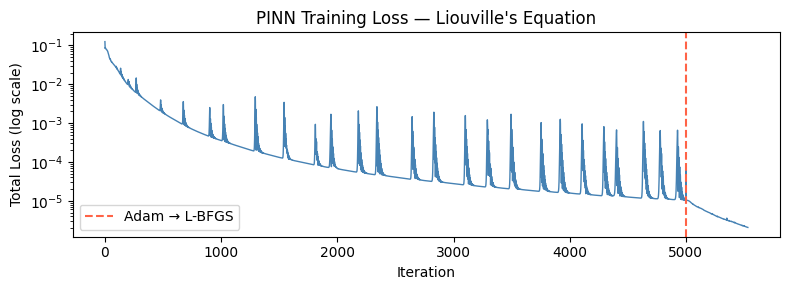

In [ ]:
# ---- Phase 2: L-BFGS -------------------------─
opt_lbfgs = optim.LBFGS(
    model.parameters(),
    max_iter=500, tolerance_grad=1e-9, tolerance_change=1e-12,
    history_size=50, line_search_fn="strong_wolfe"
)

def closure():
    opt_lbfgs.zero_grad()
    loss, _, _ = compute_loss(model)
    loss.backward()
    history.append(loss.item())
    return loss

opt_lbfgs.step(closure)
final, _, _ = compute_loss(model)
print(f"L-BFGS done.  Final loss: {final.item():.6f}")

# Training loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(history, color="steelblue", lw=1.0)
ax.axvline(x=ADAM_EP, color="tomato", ls="--", lw=1.5, label="Adam → L-BFGS")
ax.set_xlabel("Iteration"); ax.set_ylabel("Total Loss (log scale)")
ax.set_title("PINN Training Loss — Liouville's Equation")
ax.legend() 
plt.tight_layout()
plt.show()


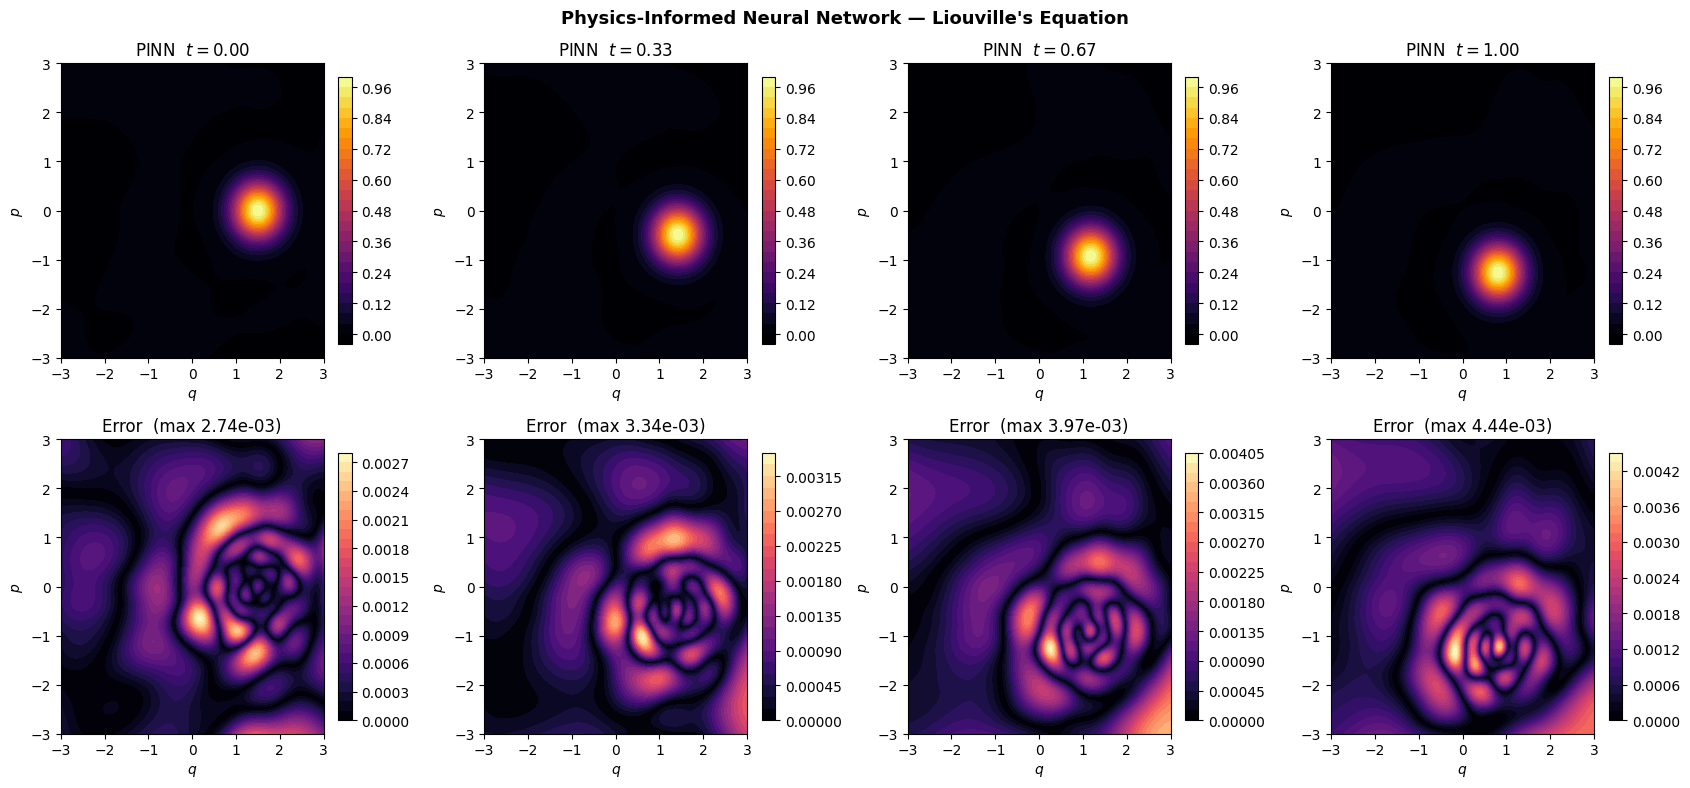

PINN — Max error: 4.44e-03  |  Mean error: 8.63e-04


In [ ]:
# ---- Evaluate PINN on a dense $(q, p)$ grid at each snapshot ─
model.eval()
Nev = 100
q_ev = np.linspace(Q_MIN, Q_MAX, Nev)
p_ev = np.linspace(P_MIN, P_MAX, Nev)
Qev, Pev = np.meshgrid(q_ev, p_ev)

def pinn_predict(t_val):
    qt = torch.tensor(Qev.ravel(), dtype=torch.float32).unsqueeze(1)
    pt = torch.tensor(Pev.ravel(), dtype=torch.float32).unsqueeze(1)
    tt = torch.full((Nev * Nev, 1), t_val, dtype=torch.float32)
    with torch.no_grad():
        return model(qt, pt, tt).numpy().reshape(Nev, Nev)

snap_times_pinn = [0.0, T_END / 3, 2 * T_END / 3, T_END]
F_pinn_snaps = [pinn_predict(t) for t in snap_times_pinn]

# PINN error at final time
F_ex_pinn = f_exact(Qev, Pev, T_END)
err_pinn   = np.abs(F_pinn_snaps[-1] - F_ex_pinn)

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for col, (F_snap, t_snap) in enumerate(zip(F_pinn_snaps, snap_times_pinn)):
    F_ref = f_exact(Qev, Pev, t_snap)

    cf0 = axes[0, col].contourf(Qev, Pev, F_snap, levels=30, cmap=CMAP, vmin=0, vmax=1)
    axes[0, col].set_title(f"PINN  $t={t_snap:.2f}$")
    axes[0, col].set_xlabel("$q$"); axes[0, col].set_ylabel("$p$")
    plt.colorbar(cf0, ax=axes[0, col], fraction=0.046)

    err = np.abs(F_snap - F_ref)
    cf1 = axes[1, col].contourf(Qev, Pev, err, levels=30, cmap="magma")
    axes[1, col].set_title(f"Error  (max {err.max():.2e})")
    axes[1, col].set_xlabel("$q$"); axes[1, col].set_ylabel("$p$")
    plt.colorbar(cf1, ax=axes[1, col], fraction=0.046)

plt.suptitle("Physics-Informed Neural Network — Liouville's Equation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"PINN — Max error: {err_pinn.max():.2e}  |  Mean error: {err_pinn.mean():.2e}")

---

## Part 3 — Side-by-Side Comparison

Final-time solutions from all three methods alongside the exact solution, plus a quantitative error summary.


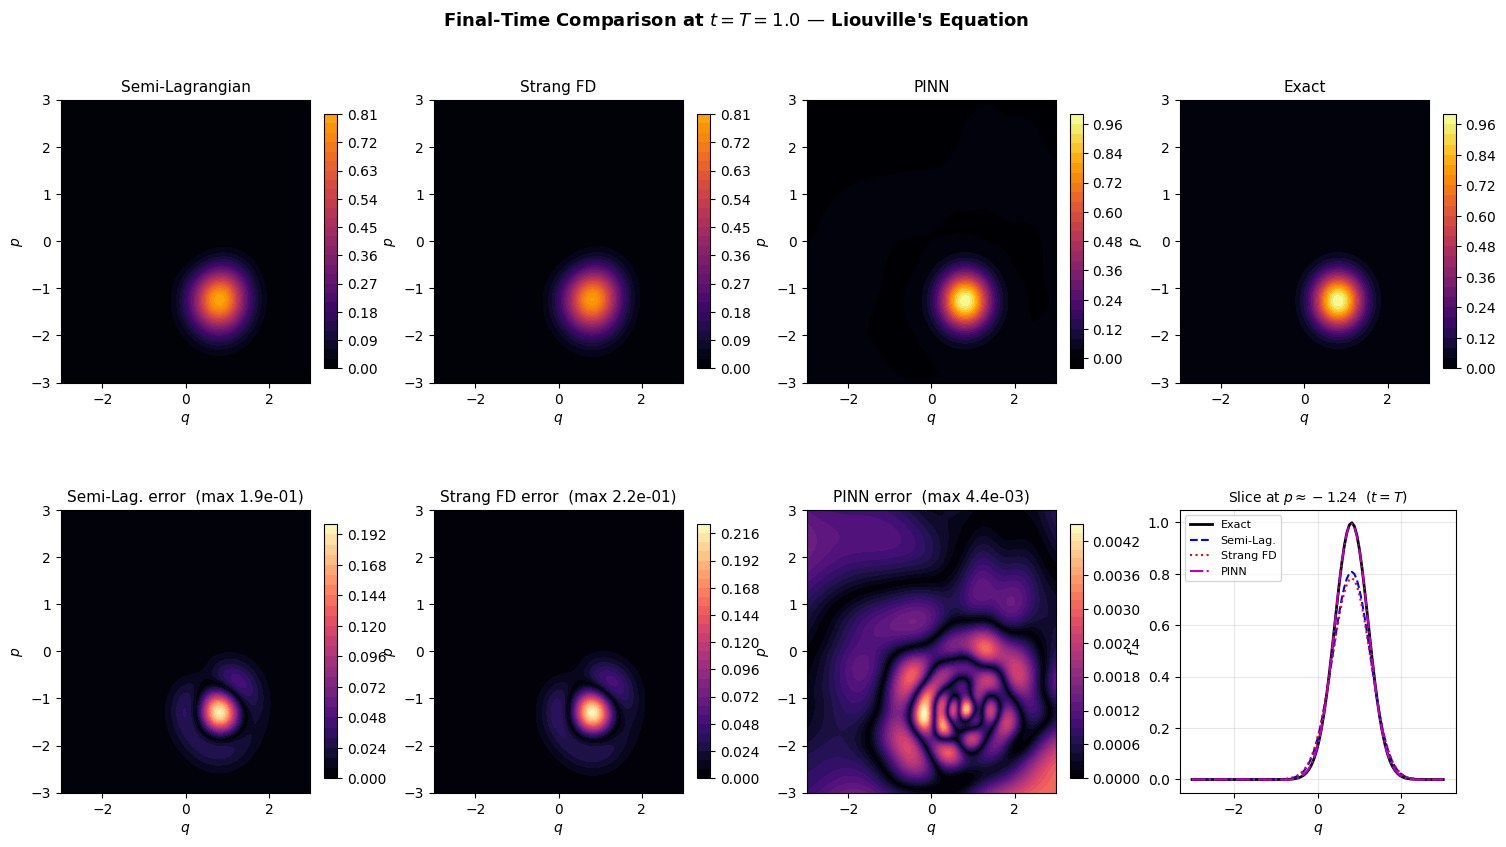

In [ ]:
# Interpolate all methods onto the common evaluation grid
def interp_to_eval(Q_src, P_src, F_src):
    q_1d = Q_src[0, :]
    p_1d = P_src[:, 0]
    itp = RegularGridInterpolator(
        (p_1d, q_1d), F_src, method="linear",
        bounds_error=False, fill_value=0.0
    )
    pts = np.stack([Pev.ravel(), Qev.ravel()], axis=1)
    return itp(pts).reshape(Nev, Nev)

F_sl_ev   = interp_to_eval(Q_sl, P_sl, F_sl_hist[-1])
F_fd_ev   = interp_to_eval(Q_fd, P_fd, F_fd_hist[-1])
F_pinn_ev = F_pinn_snaps[-1]

err_sl_ev   = np.abs(F_sl_ev   - F_ex_pinn)
err_fd_ev   = np.abs(F_fd_ev   - F_ex_pinn)
err_pinn_ev = np.abs(F_pinn_ev - F_ex_pinn)

fig = plt.figure(figsize=(18, 9))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

labels = ["Semi-Lagrangian", "Strang FD", "PINN", "Exact"]
sols   = [F_sl_ev, F_fd_ev, F_pinn_ev, F_ex_pinn]
errs   = [err_sl_ev, err_fd_ev, err_pinn_ev]
e_lbl  = ["Semi-Lag. error", "Strang FD error", "PINN error"]

for col, (lbl, sol) in enumerate(zip(labels, sols)):
    ax = fig.add_subplot(gs[0, col])
    cf = ax.contourf(Qev, Pev, sol, levels=30, cmap=CMAP, vmin=0, vmax=1)
    ax.set_title(lbl, fontsize=11); ax.set_xlabel("$q$"); ax.set_ylabel("$p$")
    plt.colorbar(cf, ax=ax, fraction=0.046)

for col, (lbl, err) in enumerate(zip(e_lbl, errs)):
    ax = fig.add_subplot(gs[1, col])
    cf = ax.contourf(Qev, Pev, err, levels=30, cmap="magma")
    ax.set_title(f"{lbl}  (max {err.max():.1e})", fontsize=11)
    ax.set_xlabel("$q$"); ax.set_ylabel("$p$")
    plt.colorbar(cf, ax=ax, fraction=0.046)

# Cross-section through Gaussian center at final time
ax_cs = fig.add_subplot(gs[1, 3])

# Centre of rotated Gaussian at T_END
qc_T = Q0 * np.cos(T_END)   # \approx 0.81
pc_T = -Q0 * np.sin(T_END)  # \approx −1.26

# Slice along $q$ at $p = pc_T$ (nearest row)
row = np.argmin(np.abs(p_ev - pc_T))
ax_cs.plot(q_ev, F_ex_pinn[row],   "k-",  lw=2,   label="Exact")
ax_cs.plot(q_ev, F_sl_ev[row],     "b--", lw=1.5, label="Semi-Lag.")
ax_cs.plot(q_ev, F_fd_ev[row],     "r:",  lw=1.5, label="Strang FD")
ax_cs.plot(q_ev, F_pinn_ev[row],   "m-.", lw=1.5, label="PINN")
ax_cs.set_title(f"Slice at $p\\approx{p_ev[row]:.2f}$  ($t=T$)", fontsize=10)
ax_cs.set_xlabel("$q$") 
ax_cs.set_ylabel("$f$")
ax_cs.legend(fontsize=8); ax_cs.grid(alpha=0.3)

fig.suptitle(f"Final-Time Comparison at $t = T = {T_END}$ — Liouville's Equation", fontsize=13, fontweight="bold")
plt.show()

In [18]:
# ---- Liouville's theorem check: total probability (integral of $f$) --------------------
# Should be conserved in time
def phase_space_integral(F_grid, q_arr, p_arr):
    """Approximate $∫∫ f dq dp via the trapezoidal rule."""
    return np.trapezoid(np.trapezoid(F_grid, q_arr, axis=1), p_arr)

q_ev_1d = q_ev
p_ev_1d = p_ev

I_exact_0  = phase_space_integral(f_init(Qev, Pev), q_ev_1d, p_ev_1d)
I_exact_T  = phase_space_integral(F_ex_pinn,  q_ev_1d, p_ev_1d)
I_sl_T     = phase_space_integral(F_sl_ev,    q_ev_1d, p_ev_1d)
I_fd_T     = phase_space_integral(F_fd_ev,    q_ev_1d, p_ev_1d)
I_pinn_T   = phase_space_integral(F_pinn_ev,  q_ev_1d, p_ev_1d)

print("=" * 62)
print(f"{'Method':<22} {'Max error':>12} {'Mean error':>12} {'∫f dqdp':>10}")
print("-" * 62)
print(f"{'Exact (t=0)':22} {'—':>12} {'—':>12} {I_exact_0:>10.4f}")
print(f"{'Exact (t=T)':22} {'—':>12} {'—':>12} {I_exact_T:>10.4f}")
print(f"{'Semi-Lagrangian':22} {err_sl_ev.max():>12.3e} {err_sl_ev.mean():>12.3e} {I_sl_T:>10.4f}")
print(f"{'Strang FD':22} {err_fd_ev.max():>12.3e} {err_fd_ev.mean():>12.3e} {I_fd_T:>10.4f}")
print(f"{'PINN':22} {err_pinn_ev.max():>12.3e} {err_pinn_ev.mean():>12.3e} {I_pinn_T:>10.4f}")
print("=" * 62)
print(f"\nNote: ∫f dqdp should be conserved (Liouville's theorem) ≈ {I_exact_0:.4f}")


Method                    Max error   Mean error    ∫f dqdp
--------------------------------------------------------------
Exact (t=0)                       —            —     1.0052
Exact (t=T)                       —            —     1.0053
Semi-Lagrangian           1.947e-01    4.338e-03     1.0051
Strang FD                 2.207e-01    5.037e-03     1.0052
PINN                      4.437e-03    8.632e-04     1.0080

Note: ∫f dqdp should be conserved (Liouville's theorem) ≈ 1.0052


---

## Summary

### About Liouville's Equation

Liouville's equation is the cornerstone of classical statistical mechanics and Hamiltonian dynamics. Key properties:

- It is a **linear, first-order hyperbolic PDE** with variable but structured coefficients $(p, -q)$ determined by the Hamiltonian.
- **Liouville's theorem**: the flow is *incompressible* in phase space — $\nabla_{(q,p)} \cdot (p, -q) = 0$, so phase-space volumes (and total probability) are conserved.
- For the harmonic oscillator the phase-space trajectories are **circles**, making it an ideal test problem.

### Method Comparison

| Aspect | Semi-Lagrangian | Strang FD (Upwind) | PINN |
|--------|----------------|-------------------|------|
| **Core idea** | Trace characteristics backward, back-interpolate | Split + 1D upwind steps | Minimise PDE + IC residuals |
| **Accuracy** | $\mathcal{O}(h^2)$ (interpolation-limited) | $\mathcal{O}(h)$ per sub-step | Depends on training |
| **Artefact** | Interpolation diffusion | Numerical diffusion (smearing) | None by design |
| **Stability** | Unconditionally stable (exact characteristics) | CFL condition required | Unconditional |
| **Conservation** | Nearly exact (bilinear interpolation loses small amounts) | Approximate conservation | Soft implicit through IC loss |
| **Mesh required** | Yes — structured phase-space grid | Yes — structured grid | No — meshfree |
| **Best for** | Regular domains + smooth solutions | Simple implementation | Complex Hamiltonians, parametric or inverse problems |

### Key Observations

- The **Semi-Lagrangian** method exploits the exact analytical characteristics of the harmonic oscillator. The only error is in the bilinear back-interpolation — this gives $\mathcal{O}(h^2)$ accuracy with *no CFL restriction*.
- **Strang FD** is straightforward to implement but first-order accurate (due to upwind diffusion). It smooths the Gaussian peak over time.
- The **PINN** requires no mesh and no CFL condition, but training a 3D space-time problem $(q, p, t)$ is costlier; careful sampling near the Gaussian support is needed to recover the full dynamics accurately.
